# Analisis Sentimen Review Mobile Legends (IMPROVED)

## Import Library

In [2]:
# Install Sastrawi library if not already installed
!pip install Sastrawi

# Data Processing
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# Text Processing
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import nltk
from nltk.tokenize import word_tokenize

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Utilities
from tqdm import tqdm
tqdm.pandas()

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Semua library berhasil diimport!")
print(f"TensorFlow version: {tf.__version__}")

I0000 00:00:1779567415.374458  225044 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779567416.383111  225044 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779567421.379199  225044 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


✓ Semua library berhasil diimport!
TensorFlow version: 2.21.0


In [3]:
# Download NLTK data (jika belum ada)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
print("✓ NLTK data siap!")

✓ NLTK data siap!


## Load Dataset

In [5]:
# Load dataset
df = pd.read_csv('mlbb_reviews.csv')

print("=" * 60)
print("INFORMASI DATASET")
print("=" * 60)
print(f"Jumlah baris: {len(df)}")
print(f"Jumlah kolom: {len(df.columns)}")
print(f"\nNama kolom: {list(df.columns)}")
print("\n5 Data Teratas:")
df.head(20)

INFORMASI DATASET
Jumlah baris: 9226
Jumlah kolom: 7

Nama kolom: ['nama_pengguna', 'rating', 'review', 'tanggal', 'versi_app', 'jumlah_like', 'balasan_developer']

5 Data Teratas:


,nama_pengguna,rating,review,tanggal,versi_app,jumlah_like,balasan_developer
0,FADIL AHMAD ILHAM,5,sangat bagus,2026-05-22 23:49:52,2.1.67.11733,0,NaN
1,Putu “Gopal” Gopala,1,gk pernah di kasi menang,2026-05-22 23:49:30,2.1.67.11733,0,"Halo Kak,\nKami mohon maaf atas pengalaman kur..."
2,renita wulandr,1,"game stres, bintang 1 sangat tidak rekomen",2026-05-22 23:49:21,NaN,0,"Halo Kak,\nKami mohon maaf atas pengalaman kur..."
3,Saddam wise cist,5,game babi ini,2026-05-22 23:49:19,2.1.31.11233,0,NaN
4,Muzda Kunyukk,1,game rusakkkkkk najis bet mainin ni game,2026-05-22 23:48:19,2.1.67.11733,0,NaN
5,Majid Afandi,1,aneh tiap mau naik rank turun terus,2026-05-22 23:47:20,2.1.67.11733,0,NaN
6,Putri Saci,5,Seru banget permainan ini,2026-05-22 23:44:16,2.1.61.11705,0,NaN
7,alfian_96_kno alfian,1,KENAPA SI KALO HABIS WIN STREAK SELALU DIKASIH...,2026-05-22 23:43:53,2.1.67.11733,0,NaN
8,Sendy Angga Saputra,1,matchmaking yang tidak seimbang untuk player s...,2026-05-22 23:43:50,2.1.67.11733,0,NaN
9,great damage,5,"apalah, server sering lagggg, ampe 450 ??!!! b...",2026-05-22 23:40:22,2.1.61.11705,0,NaN


In [6]:
# Info dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9226 entries, 0 to 9225
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   nama_pengguna      9226 non-null   str  
 1   rating             9226 non-null   int64
 2   review             9226 non-null   str  
 3   tanggal            9226 non-null   str  
 4   versi_app          6601 non-null   str  
 5   jumlah_like        9226 non-null   int64
 6   balasan_developer  3176 non-null   str  
dtypes: int64(2), str(5)
memory usage: 504.7 KB


In [7]:
# Statistik deskriptif
df.describe()

,rating,jumlah_like
count,9226.000000,9226.000000
mean,2.470952,3.297529
std,1.808523,185.134631
min,1.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,0.000000
75%,5.000000,0.000000
max,5.000000,16961.000000


## Exploratory Data Analysis (EDA)

In [10]:
# Cek missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing Values:
nama_pengguna           0
rating                  0
review                  0
tanggal                 0
versi_app            2625
jumlah_like             0
balasan_developer    6050
dtype: int64

Total missing values: 8675


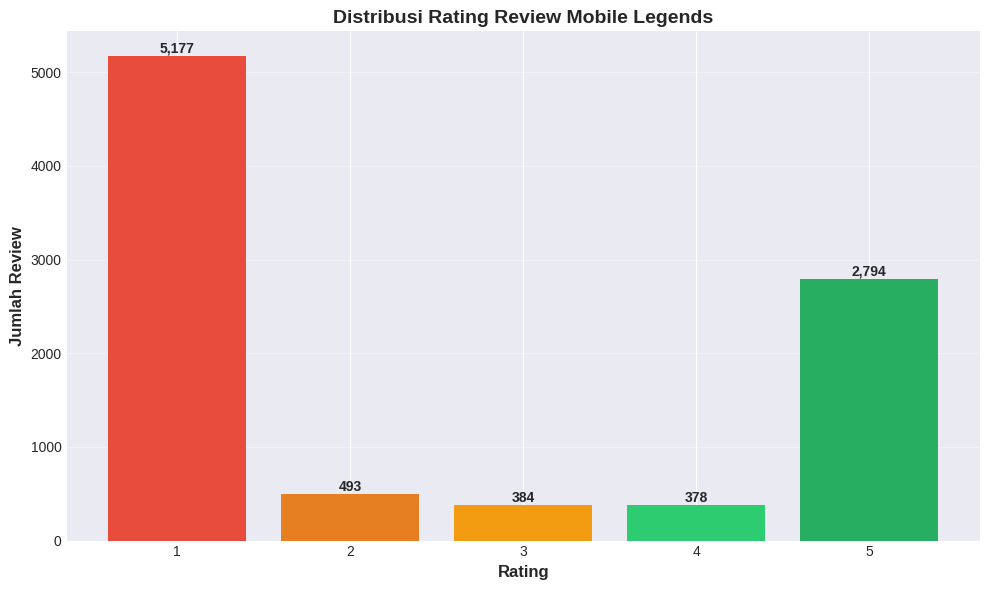


Persentase Rating:
rating
1    56.11
2     5.34
3     4.16
4     4.10
5    30.28
Name: proportion, dtype: float64


In [8]:
# Distribusi Rating
plt.figure(figsize=(10, 6))
rating_counts = df['rating'].value_counts().sort_index()
bars = plt.bar(rating_counts.index, rating_counts.values, color=['#e74c3c', '#e67e22', '#f39c12', '#2ecc71', '#27ae60'])
plt.xlabel('Rating', fontsize=12, fontweight='bold')
plt.ylabel('Jumlah Review', fontsize=12, fontweight='bold')
plt.title('Distribusi Rating Review Mobile Legends', fontsize=14, fontweight='bold')
plt.xticks([1, 2, 3, 4, 5])

# Tambahkan nilai di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPersentase Rating:")
print((df['rating'].value_counts(normalize=True).sort_index() * 100).round(2))

Statistik Panjang Review (karakter):
Minimum: 1
Maksimum: 500
Rata-rata: 97.84
Median: 65.00


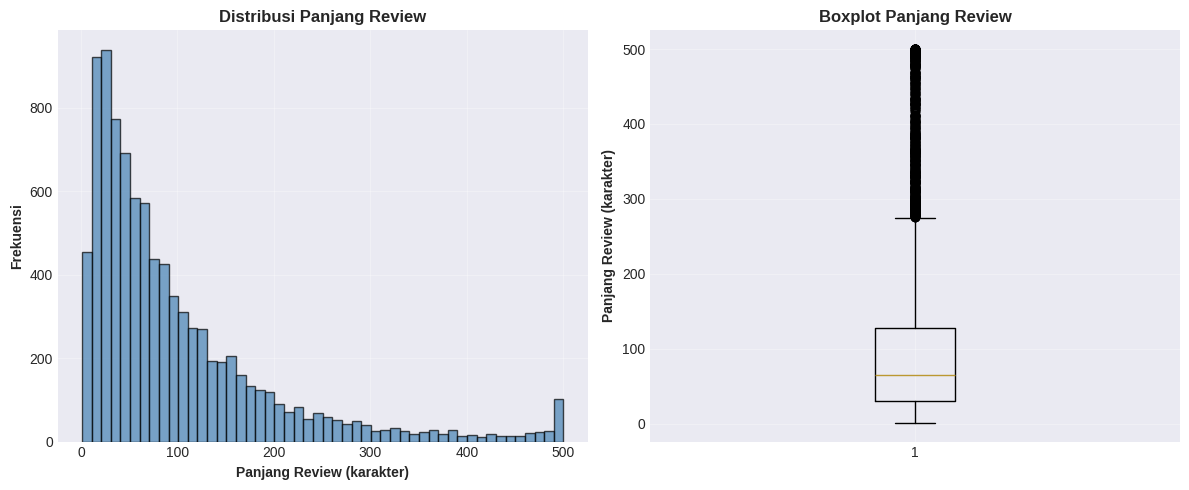

In [9]:
# Statistik panjang review
df['panjang_review'] = df['review'].astype(str).apply(len)

print("Statistik Panjang Review (karakter):")
print(f"Minimum: {df['panjang_review'].min()}")
print(f"Maksimum: {df['panjang_review'].max()}")
print(f"Rata-rata: {df['panjang_review'].mean():.2f}")
print(f"Median: {df['panjang_review'].median():.2f}")

# Visualisasi distribusi panjang review
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['panjang_review'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Panjang Review (karakter)', fontweight='bold')
plt.ylabel('Frekuensi', fontweight='bold')
plt.title('Distribusi Panjang Review', fontweight='bold')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(df['panjang_review'], vert=True)
plt.ylabel('Panjang Review (karakter)', fontweight='bold')
plt.title('Boxplot Panjang Review', fontweight='bold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Contoh review berdasarkan rating
print("=" * 80)
print("CONTOH REVIEW BERDASARKAN RATING")
print("=" * 80)

for rating in [5, 3, 1]:
    print(f"\n{'='*80}")
    print(f"Rating {rating} ⭐")
    print(f"{'='*80}")
    sample = df[df['rating'] == rating]['review'].head(3)
    for idx, review in enumerate(sample, 1):
        print(f"{idx}. {review[:200]}...")
        print("-" * 80)

CONTOH REVIEW BERDASARKAN RATING

Rating 5 ⭐
1. sangat bagus...
--------------------------------------------------------------------------------
2. game babi ini...
--------------------------------------------------------------------------------
3. Seru banget permainan ini...
--------------------------------------------------------------------------------

Rating 3 ⭐
1. matchmaking tidak seimbang. sering ketemu team yang tidak memahami permainan dan skil nya buruk... merugikan teman satu team...
--------------------------------------------------------------------------------
2. masa gua main game ini kalah terus...
--------------------------------------------------------------------------------
3. montoon aku lose streek 10 kali...
--------------------------------------------------------------------------------

Rating 1 ⭐
1. gk pernah di kasi menang...
--------------------------------------------------------------------------------
2. game stres, bintang 1 sangat tidak rekomen...
---

## DATA PREPARATION

### Labeling Sentimen

In [11]:
def label_sentiment(rating):
    """
    Fungsi untuk melabeli sentimen berdasarkan rating
    """
    if rating >= 4:
        return 'positif'
    elif rating == 3:
        return 'netral'
    else:
        return 'negatif'

# Terapkan labeling
df['sentimen'] = df['rating'].apply(label_sentiment)

print("Distribusi Sentimen:")
print(df['sentimen'].value_counts())
print("\nPersentase:")
print((df['sentimen'].value_counts(normalize=True) * 100).round(2))

Distribusi Sentimen:
sentimen
negatif    5670
positif    3172
netral      384
Name: count, dtype: int64

Persentase:
sentimen
negatif    61.46
positif    34.38
netral      4.16
Name: proportion, dtype: float64


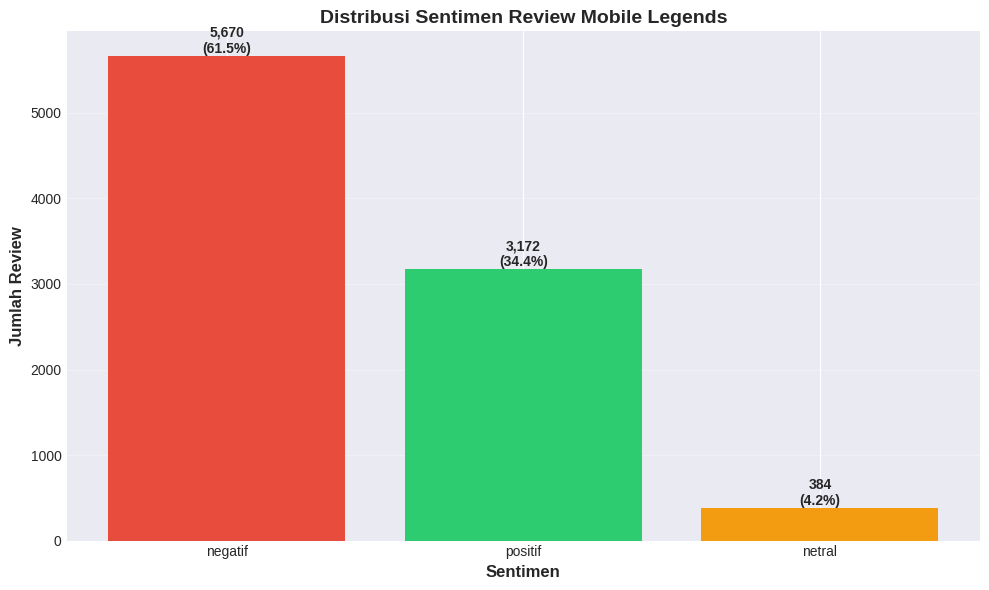

In [12]:
# Visualisasi distribusi sentimen
plt.figure(figsize=(10, 6))
sentiment_counts = df['sentimen'].value_counts()
colors = {'positif': '#2ecc71', 'netral': '#f39c12', 'negatif': '#e74c3c'}
bars = plt.bar(sentiment_counts.index, sentiment_counts.values,
               color=[colors[x] for x in sentiment_counts.index])

plt.xlabel('Sentimen', fontsize=12, fontweight='bold')
plt.ylabel('Jumlah Review', fontsize=12, fontweight='bold')
plt.title('Distribusi Sentimen Review Mobile Legends', fontsize=14, fontweight='bold')

# Tambahkan nilai dan persentase di atas bar
total = len(df)
for bar in bars:
    height = bar.get_height()
    percentage = (height / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}\n({percentage:.1f}%)',
             ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Text Preprocessing (IMPROVED)

In [13]:
# Inisialisasi Sastrawi
factory_stemmer = StemmerFactory()
stemmer = factory_stemmer.create_stemmer()

factory_stopword = StopWordRemoverFactory()
stopword_remover = factory_stopword.create_stop_word_remover()

print("✓ Sastrawi Stemmer dan Stopword Remover siap!")

✓ Sastrawi Stemmer dan Stopword Remover siap!


In [16]:
import re
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Inisialisasi
stopword_remover = StopWordRemoverFactory().create_stop_word_remover()
stemmer = StemmerFactory().create_stemmer()

# ✅ KAMUS SLANG YANG LEBIH LENGKAP (khusus game review)
slang_dict = {
    # Negasi
    'gk': 'tidak', 'gak': 'tidak', 'ga': 'tidak', 'ngga': 'tidak', 'nggak': 'tidak',
    'nda': 'tidak', 'ndak': 'tidak', 'tdk': 'tidak',
    
    # Umum
    'bgt': 'banget', 'bet': 'banget', 'bgtt': 'banget',
    'tp': 'tapi', 'jg': 'juga', 'jga': 'juga',
    'udh': 'sudah', 'sdh': 'sudah', 'udah': 'sudah',
    'aja': 'saja', 'aj': 'saja', 'doang': 'saja',
    'sy': 'saya', 'gw': 'saya', 'gue': 'saya', 'gua': 'saya',
    'lu': 'kamu', 'loe': 'kamu', 'kalo': 'kalau', 'kl': 'kalau',
    'ni': 'ini', 'itu': 'itu', 'nya': 'nya',
    
    # Gaming Specific
    'win': 'menang', 'lose': 'kalah', 'streak': 'beruntun',
    'rank': 'peringkat', 'match': 'pertandingan', 'mm': 'matchmaking',
    'toxic': 'buruk', 'busuk': 'buruk', 'jelek': 'buruk',
    'lag': 'lambat', 'ngeleg': 'lambat', 'ngelag': 'lambat',
    'bug': 'error', 'rusak': 'error', 'babi': 'buruk',
    'anjing': 'buruk', 'sial': 'buruk', 'najis': 'buruk',
    'parah': 'buruk', 'banget': 'buruk',
    'seru': 'bagus', 'mantap': 'bagus', 'keren': 'bagus',
    'recommended': 'rekomendasi', 'rekom': 'rekomendasi',
    'stress': 'stres', 'estres': 'stres',
}

def preprocess_text(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    # Lowercase
    text = text.lower()

    # Normalisasi repeating characters (rusakkkkk → rusak)
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # Hapus URL, mention, hashtag
    text = re.sub(r'http\S+|www\S+|https\S+|@\w+|#\w+', '', text)

    # Hapus angka dan karakter spesial
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    if not text:
        return ""

    # Slang replacement
    words = text.split()
    words = [slang_dict.get(word, word) for word in words]
    text = ' '.join(words)

    # Simpan negasi sebelum stopword removal
    negasi_words = ['tidak', 'bukan', 'jangan', 'ga', 'gak']
    has_negasi = any(neg in text for neg in negasi_words)

    # Stopword Removal
    text = stopword_remover.remove(text)

    # Kembalikan negasi jika hilang
    if has_negasi and not any(neg in text for neg in ['tidak', 'bukan', 'jangan']):
        text = 'tidak ' + text

    # Stemming
    text = stemmer.stem(text)

    return text.strip()


# === TESTING ===
test_cases = [
    "sangat bagus",
    "gk pernah di kasi menang",
    "game stres, bintang 1 sangat tidak rekomen",
    "game babi ini",
    "game rusakkkkk najis bet mainin ni game",
    "aneh tiap mau naik rank turun terus",
    "Seru banget permainan ini",
    "KENAPA SI KALO HABIS WIN STREAK SELALU DIKASIH...",
    "matchmaking yang tidak seimbang untuk player s...",
    "apalah, server sering lagggg, ampe 450 ??!!!",
    "pembagian tim nya sangat tidak adil GAME BUSUKKK",
    "game penamba estres",
    "gua di kasih lose treak udah 4 hari parah lu",
    "game bikin pemain solo stress gk masuk akal",
    "Game sial penyeimbang matching ndk ngotak bot",
    "AYO LAH GAME INI DIHAPUS AJA, GA SEHAT, TOXIC",
    "kok punya aku gak ada suaranya sih",
    "pihak moonton saya tidak bisa main reng",
    "hama ngeleg wae anjing"
]

print("🔄 Hasil Preprocessing yang Dioptimalkan:\n")
for i, text in enumerate(test_cases, 1):
    cleaned = preprocess_text(text)
    print(f"{i:2d}. Original : {text}")
    print(f"    Cleaned  : {cleaned}")
    print("-" * 80)

🔄 Hasil Preprocessing yang Dioptimalkan:

 1. Original : sangat bagus
    Cleaned  : tidak sangat bagus
--------------------------------------------------------------------------------
 2. Original : gk pernah di kasi menang
    Cleaned  : tidak pernah kasi menang
--------------------------------------------------------------------------------
 3. Original : game stres, bintang 1 sangat tidak rekomen
    Cleaned  : tidak game stres bintang sangat rekomen
--------------------------------------------------------------------------------
 4. Original : game babi ini
    Cleaned  : tidak game buruk
--------------------------------------------------------------------------------
 5. Original : game rusakkkkk najis bet mainin ni game
    Cleaned  : tidak game error buruk banget mainin game
--------------------------------------------------------------------------------
 6. Original : aneh tiap mau naik rank turun terus
    Cleaned  : aneh tiap mau naik peringkat turun terus
------------------

In [18]:
# Terapkan preprocessing ke seluruh dataset
print("Memproses teks... (ini mungkin memakan waktu beberapa menit)")
df['review_bersih'] = df['review'].progress_apply(preprocess_text)

print("\n✓ Preprocessing selesai!")
print("\nContoh hasil preprocessing:")
print("=" * 100)
for idx in range(5):
    print(f"\nOriginal: {df['review'].iloc[idx][:100]}...")
    print(f"Cleaned:  {df['review_bersih'].iloc[idx][:100]}...")
    print("-" * 100)

Memproses teks... (ini mungkin memakan waktu beberapa menit)


100%|██████████| 9226/9226 [07:42<00:00, 19.96it/s]


✓ Preprocessing selesai!

Contoh hasil preprocessing:

Original: sangat bagus...
Cleaned:  sangat bagus...
----------------------------------------------------------------------------------------------------

Original: gk pernah di kasi menang...
Cleaned:  pernah kasi menang...
----------------------------------------------------------------------------------------------------

Original: game stres, bintang 1 sangat tidak rekomen...
Cleaned:  tidak game stres bintang sangat rekomen...
----------------------------------------------------------------------------------------------------

Original: game babi ini...
Cleaned:  game babi...
----------------------------------------------------------------------------------------------------

Original: game rusakkkkkk najis bet mainin ni game...
Cleaned:  game rusak najis banget mainin game...
----------------------------------------------------------------------------------------------------


In [19]:
# Hapus review yang kosong setelah preprocessing
df = df[df['review_bersih'].str.strip() != '']
df = df.reset_index(drop=True)

print(f"Total data setelah preprocessing: {len(df)}")

Total data setelah preprocessing: 9186


### Word Cloud Visualization

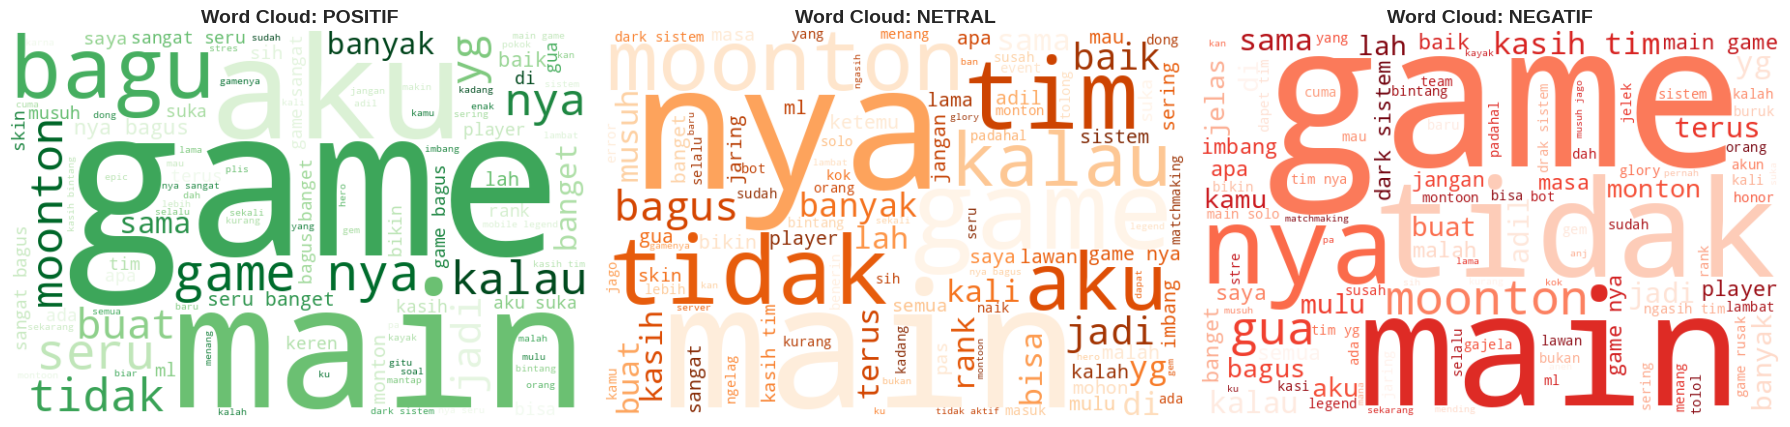

In [20]:
# Word Cloud untuk setiap sentimen
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sentiments = ['positif', 'netral', 'negatif']
colors = ['Greens', 'Oranges', 'Reds']

for idx, (sentiment, color) in enumerate(zip(sentiments, colors)):
    text = ' '.join(df[df['sentimen'] == sentiment]['review_bersih'])

    wordcloud = WordCloud(width=600, height=400,
                          background_color='white',
                          colormap=color,
                          max_words=100).generate(text)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Word Cloud: {sentiment.upper()}', fontsize=14, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

### Encoding Label Sentimen

In [21]:
# Mapping sentimen ke angka
sentiment_mapping = {'negatif': 0, 'netral': 1, 'positif': 2}
df['label'] = df['sentimen'].map(sentiment_mapping)

print("Mapping Sentimen:")
print(sentiment_mapping)
print("\nDistribusi Label:")
print(df['label'].value_counts().sort_index())

Mapping Sentimen:
{'negatif': 0, 'netral': 1, 'positif': 2}

Distribusi Label:
label
0    5660
1     382
2    3144
Name: count, dtype: int64


## MACHINE LEARNING MODELS

### Split Data untuk ML Models (RF & SVM)

In [22]:
# ✅ FIXED: Variabel terpisah untuk ML models
X_ml = df['review_bersih'].values
y_ml = df['label'].values

# Split: Train (70%) dan Temp (30%)
X_train_ml, X_temp_ml, y_train_ml, y_temp_ml = train_test_split(
    X_ml, y_ml, test_size=0.3, random_state=42, stratify=y_ml
)

# Split Temp menjadi Validation (15%) dan Test (15%)
X_val_ml, X_test_ml, y_val_ml, y_test_ml = train_test_split(
    X_temp_ml, y_temp_ml, test_size=0.5, random_state=42, stratify=y_temp_ml
)

print("=" * 60)
print("PEMBAGIAN DATASET (ML MODELS)")
print("=" * 60)
print(f"Total data: {len(X_ml):,}")
print(f"Training set: {len(X_train_ml):,} ({len(X_train_ml)/len(X_ml)*100:.1f}%)")
print(f"Validation set: {len(X_val_ml):,} ({len(X_val_ml)/len(X_ml)*100:.1f}%)")
print(f"Testing set: {len(X_test_ml):,} ({len(X_test_ml)/len(X_ml)*100:.1f}%)")

print("\nDistribusi Kelas pada Training Set:")
print(pd.Series(y_train_ml).value_counts().sort_index())

print("\nDistribusi Kelas pada Validation Set:")
print(pd.Series(y_val_ml).value_counts().sort_index())

print("\nDistribusi Kelas pada Testing Set:")
print(pd.Series(y_test_ml).value_counts().sort_index())

PEMBAGIAN DATASET (ML MODELS)
Total data: 9,186
Training set: 6,430 (70.0%)
Validation set: 1,378 (15.0%)
Testing set: 1,378 (15.0%)

Distribusi Kelas pada Training Set:
0    3962
1     267
2    2201
Name: count, dtype: int64

Distribusi Kelas pada Validation Set:
0    849
1     58
2    471
Name: count, dtype: int64

Distribusi Kelas pada Testing Set:
0    849
1     57
2    472
Name: count, dtype: int64


### Model 1: Random Forest + TF-IDF (IMPROVED)

In [23]:
print("="*60)
print("SKEMA 1: RANDOM FOREST + TF-IDF (IMPROVED)")
print("="*60)

# ✅ IMPROVED: TF-IDF dengan parameter lebih optimal
print("\n[1/3] Ekstraksi fitur dengan TF-IDF...")
tfidf_vectorizer = TfidfVectorizer(
    max_features=15000,      # ✅ Naik dari 5000
    ngram_range=(1, 3),      # ✅ Tambah trigram
    min_df=2,                # ✅ Buang kata sangat jarang
    sublinear_tf=True,       # ✅ Log scaling TF
    analyzer='word'
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_ml)
X_val_tfidf = tfidf_vectorizer.transform(X_val_ml)
X_test_tfidf = tfidf_vectorizer.transform(X_test_ml)

print(f"✓ Shape TF-IDF Training: {X_train_tfidf.shape}")
print(f"✓ Shape TF-IDF Validation: {X_val_tfidf.shape}")
print(f"✓ Shape TF-IDF Testing: {X_test_tfidf.shape}")

# ✅ IMPROVED: Random Forest dengan hyperparameter lebih baik
print("\n[2/3] Melatih model Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=300,           # ✅ Naik dari 100
    max_depth=None,             # ✅ Biarkan pohon tumbuh penuh
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',    # ✅ Handle imbalanced data
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_model.fit(X_train_tfidf, y_train_ml)
print("✓ Training selesai!")

# 3. Evaluasi
print("\n[3/3] Evaluasi model...")
y_pred_rf_train = rf_model.predict(X_train_tfidf)
y_pred_rf_val = rf_model.predict(X_val_tfidf)
y_pred_rf_test = rf_model.predict(X_test_tfidf)

acc_train_rf = accuracy_score(y_train_ml, y_pred_rf_train)
acc_val_rf = accuracy_score(y_val_ml, y_pred_rf_val)
acc_test_rf = accuracy_score(y_test_ml, y_pred_rf_test)

print(f"\n{'='*60}")
print("HASIL RANDOM FOREST")
print(f"{'='*60}")
print(f"Akurasi Training: {acc_train_rf*100:.2f}%")
print(f"Akurasi Validation: {acc_val_rf*100:.2f}%")
print(f"Akurasi Testing: {acc_test_rf*100:.2f}%")

SKEMA 1: RANDOM FOREST + TF-IDF (IMPROVED)

[1/3] Ekstraksi fitur dengan TF-IDF...
✓ Shape TF-IDF Training: (6430, 15000)
✓ Shape TF-IDF Validation: (1378, 15000)
✓ Shape TF-IDF Testing: (1378, 15000)

[2/3] Melatih model Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    4.3s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s


✓ Training selesai!

[3/3] Evaluasi model...


[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.2s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.3s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s



HASIL RANDOM FOREST
Akurasi Training: 89.70%
Akurasi Validation: 81.71%
Akurasi Testing: 78.66%


[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.1s finished


In [24]:
# Classification Report Random Forest
print("\nClassification Report (Testing Set):")
print(classification_report(y_test_ml, y_pred_rf_test,
                          target_names=['Negatif', 'Netral', 'Positif']))


Classification Report (Testing Set):
              precision    recall  f1-score   support

     Negatif       0.82      0.86      0.84       849
      Netral       0.12      0.02      0.03        57
     Positif       0.73      0.74      0.73       472

    accuracy                           0.79      1378
   macro avg       0.56      0.54      0.54      1378
weighted avg       0.76      0.79      0.77      1378



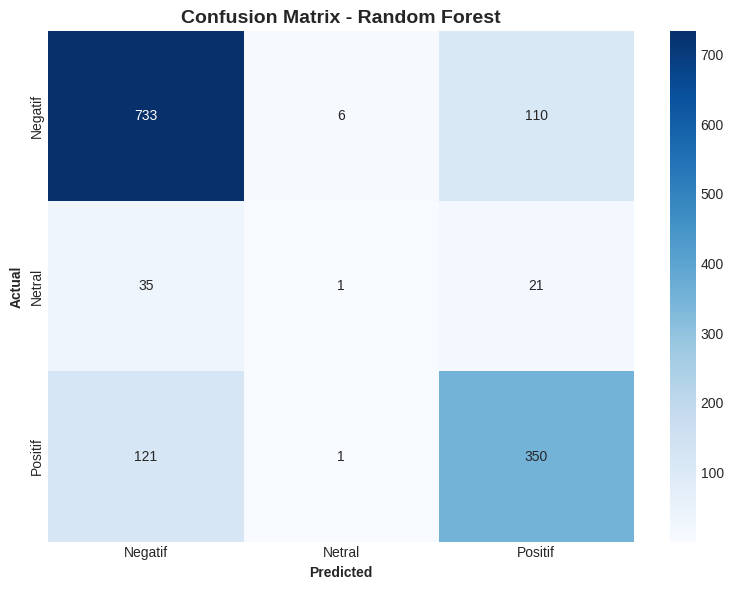

In [25]:
# Confusion Matrix Random Forest
cm_rf = confusion_matrix(y_test_ml, y_pred_rf_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Netral', 'Positif'],
            yticklabels=['Negatif', 'Netral', 'Positif'])
plt.title('Confusion Matrix - Random Forest', fontweight='bold', fontsize=14)
plt.ylabel('Actual', fontweight='bold')
plt.xlabel('Predicted', fontweight='bold')
plt.tight_layout()
plt.show()

### Model 2: SVM + TF-IDF (IMPROVED)

In [26]:
print("="*60)
print("SKEMA 2: SUPPORT VECTOR MACHINE (SVM) + TF-IDF (IMPROVED)")
print("="*60)

# ✅ IMPROVED: SVM dengan parameter lebih baik
print("\n[1/2] Melatih model SVM...")
svm_model = SVC(
    kernel='linear',
    C=5.0,                   # ✅ Naik dari 1.0
    probability=True,        # ✅ Untuk predict_proba
    class_weight='balanced', # ✅ Handle imbalanced data
    random_state=42,
    verbose=True
)

svm_model.fit(X_train_tfidf, y_train_ml)
print("✓ Training selesai!")

# Evaluasi
print("\n[2/2] Evaluasi model...")
y_pred_svm_train = svm_model.predict(X_train_tfidf)
y_pred_svm_val = svm_model.predict(X_val_tfidf)
y_pred_svm_test = svm_model.predict(X_test_tfidf)

acc_train_svm = accuracy_score(y_train_ml, y_pred_svm_train)
acc_val_svm = accuracy_score(y_val_ml, y_pred_svm_val)
acc_test_svm = accuracy_score(y_test_ml, y_pred_svm_test)

print(f"\n{'='*60}")
print("HASIL SVM")
print(f"{'='*60}")
print(f"Akurasi Training: {acc_train_svm*100:.2f}%")
print(f"Akurasi Validation: {acc_val_svm*100:.2f}%")
print(f"Akurasi Testing: {acc_test_svm*100:.2f}%")

SKEMA 2: SUPPORT VECTOR MACHINE (SVM) + TF-IDF (IMPROVED)

[1/2] Melatih model SVM...
[LibSVM]✓ Training selesai!

[2/2] Evaluasi model...

HASIL SVM
Akurasi Training: 98.52%
Akurasi Validation: 79.39%
Akurasi Testing: 77.65%


In [27]:
# Classification Report SVM
print("\nClassification Report (Testing Set):")
print(classification_report(y_test_ml, y_pred_svm_test,
                          target_names=['Negatif', 'Netral', 'Positif']))


Classification Report (Testing Set):
              precision    recall  f1-score   support

     Negatif       0.82      0.85      0.84       849
      Netral       0.04      0.02      0.02        57
     Positif       0.73      0.74      0.74       472

    accuracy                           0.78      1378
   macro avg       0.53      0.54      0.53      1378
weighted avg       0.76      0.78      0.77      1378



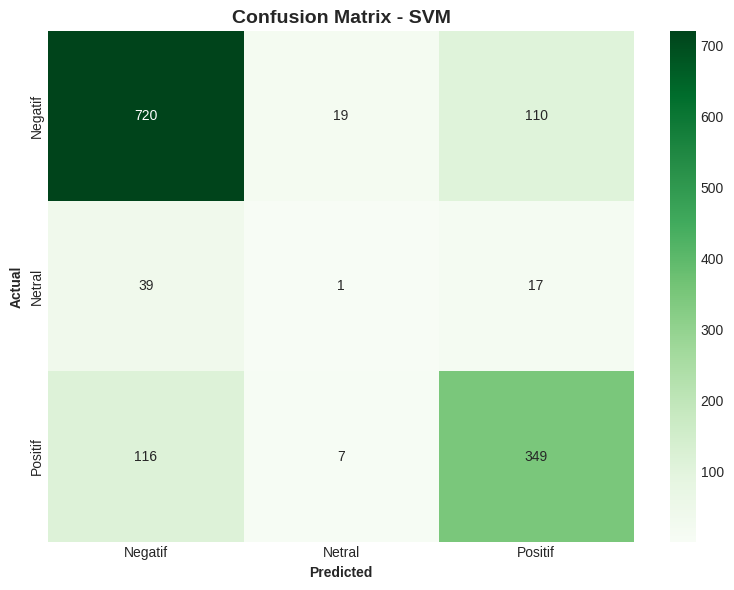

In [28]:
# Confusion Matrix SVM
cm_svm = confusion_matrix(y_test_ml, y_pred_svm_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negatif', 'Netral', 'Positif'],
            yticklabels=['Negatif', 'Netral', 'Positif'])
plt.title('Confusion Matrix - SVM', fontweight='bold', fontsize=14)
plt.ylabel('Actual', fontweight='bold')
plt.xlabel('Predicted', fontweight='bold')
plt.tight_layout()
plt.show()

## DEEP LEARNING MODEL

### Preparasi Data untuk LSTM

In [29]:
print("\n[1/4] Mempersiapkan data untuk LSTM...")

# Ambil teks dan label
texts = df['review'].astype(str).values
labels = df['label'].values

print("Distribusi Label:")
print(pd.Series(labels).value_counts())

# ✅ IMPROVED: Vocabulary size dan max length yang lebih optimal
MAX_VOCAB_SIZE = 10000  # ✅ Naik dari 1000
MAX_LEN = 100           # ✅ Turun dari 128 (lebih efisien)

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
X_lstm = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

# Split Data
X_train_lstm, X_temp_lstm, y_train_lstm, y_temp_lstm = train_test_split(
    X_lstm, labels, test_size=0.2, random_state=42, stratify=labels
)

X_val_lstm, X_test_lstm, y_val_lstm, y_test_lstm = train_test_split(
    X_temp_lstm, y_temp_lstm, test_size=0.5, random_state=42, stratify=y_temp_lstm
)

print(f"\n✅ Data siap digunakan!")
print(f"X_train shape : {X_train_lstm.shape}")
print(f"X_val shape   : {X_val_lstm.shape}")
print(f"X_test shape  : {X_test_lstm.shape}")


[1/4] Mempersiapkan data untuk LSTM...
Distribusi Label:
0    5660
2    3144
1     382
Name: count, dtype: int64

✅ Data siap digunakan!
X_train shape : (7348, 100)
X_val shape   : (919, 100)
X_test shape  : (919, 100)


### Model 3: Bidirectional LSTM (NEW!)

In [30]:
print("\n[2/4] Membangun arsitektur Bidirectional LSTM...")

# ✅ NEW: Bidirectional LSTM Architecture
lstm_model = Sequential([
    Embedding(MAX_VOCAB_SIZE, 128, input_length=MAX_LEN),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(64)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✓ Model LSTM siap dilatih!")
print(lstm_model.summary())


[2/4] Membangun arsitektur Bidirectional LSTM...
✓ Model LSTM siap dilatih!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [31]:
# Training dengan callbacks
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced',
                                   classes=np.unique(y_train_lstm),
                                   y=y_train_lstm)
class_weight_dict = dict(enumerate(class_weights))

print("\n[3/4] Melatih model LSTM...")

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

# Training
history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=20,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\n✓ Training selesai!")


[3/4] Melatih model LSTM...
Epoch 1/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 66s 532ms/step - accuracy: 0.5312 - loss: 0.9849 - val_accuracy: 0.7998 - val_loss: 0.7048 - learning_rate: 0.0010
Epoch 2/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 77s 491ms/step - accuracy: 0.6990 - loss: 0.8047 - val_accuracy: 0.7138 - val_loss: 0.7459 - learning_rate: 0.0010
Epoch 3/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.8004 - loss: 0.5848
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
115/115 ━━━━━━━━━━━━━━━━━━━━ 81s 485ms/step - accuracy: 0.7960 - loss: 0.5901 - val_accuracy: 0.7029 - val_loss: 0.7819 - learning_rate: 0.0010
Epoch 4/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 80s 468ms/step - accuracy: 0.8668 - loss: 0.3961 - val_accuracy: 0.7780 - val_loss: 0.6631 - learning_rate: 5.0000e-04
Epoch 5/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 82s 465ms/step - accuracy: 0.8880 - loss: 0.3190 - val_accuracy: 0.7203 - val_loss: 0.7892 - learning_rate: 5.0000e-04
Epoch 6/20
115/115 ━━━━━━━━━━━━━━━━

In [32]:
# Evaluasi LSTM
print("\n[4/4] Evaluasi model LSTM...")

# Evaluasi pada setiap set
loss_train, acc_train_lstm = lstm_model.evaluate(X_train_lstm, y_train_lstm, verbose=0)
loss_val, acc_val_lstm = lstm_model.evaluate(X_val_lstm, y_val_lstm, verbose=0)
loss_test, acc_test_lstm = lstm_model.evaluate(X_test_lstm, y_test_lstm, verbose=0)

print(f"\n{'='*60}")
print("HASIL BIDIRECTIONAL LSTM")
print(f"{'='*60}")
print(f"Akurasi Training: {acc_train_lstm*100:.2f}%")
print(f"Akurasi Validation: {acc_val_lstm*100:.2f}%")
print(f"Akurasi Testing: {acc_test_lstm*100:.2f}%")

# Prediksi
y_pred_lstm_test = np.argmax(lstm_model.predict(X_test_lstm, verbose=0), axis=1)


[4/4] Evaluasi model LSTM...

HASIL BIDIRECTIONAL LSTM
Akurasi Training: 90.57%
Akurasi Validation: 77.80%
Akurasi Testing: 74.54%


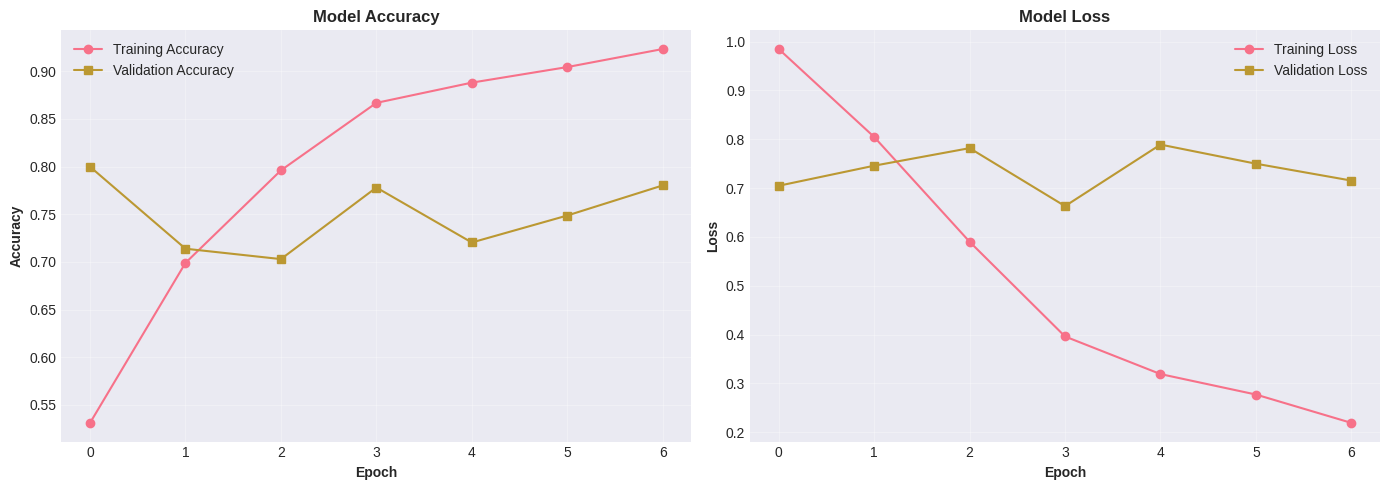

In [33]:
# Plot Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
axes[0].set_title('Model Accuracy', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Epoch', fontweight='bold')
axes[0].set_ylabel('Accuracy', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Training Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Validation Loss', marker='s')
axes[1].set_title('Model Loss', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Epoch', fontweight='bold')
axes[1].set_ylabel('Loss', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
# Classification Report LSTM
print("\nClassification Report (Testing Set):")
print(classification_report(y_test_lstm, y_pred_lstm_test,
                          target_names=['Negatif', 'Netral', 'Positif']))


Classification Report (Testing Set):
              precision    recall  f1-score   support

     Negatif       0.86      0.79      0.82       567
      Netral       0.06      0.18      0.09        38
     Positif       0.80      0.73      0.77       314

    accuracy                           0.75       919
   macro avg       0.58      0.57      0.56       919
weighted avg       0.81      0.75      0.77       919



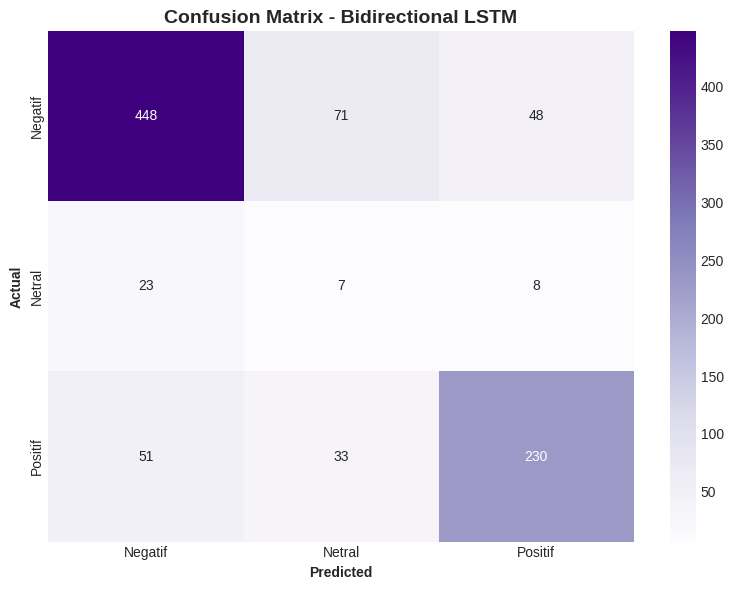

In [35]:
# Confusion Matrix LSTM
cm_lstm = confusion_matrix(y_test_lstm, y_pred_lstm_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Negatif', 'Netral', 'Positif'],
            yticklabels=['Negatif', 'Netral', 'Positif'])
plt.title('Confusion Matrix - Bidirectional LSTM', fontweight='bold', fontsize=14)
plt.ylabel('Actual', fontweight='bold')
plt.xlabel('Predicted', fontweight='bold')
plt.tight_layout()
plt.show()

## MODEL COMPARISON

In [36]:
# ✅ FIXED: Perbandingan dengan dataset yang konsisten
print("=" * 80)
print("PERBANDINGAN PERFORMA MODEL (TESTING SET)")
print("=" * 80)

def calculate_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted'),
        'Recall': recall_score(y_true, y_pred, average='weighted'),
        'F1-Score': f1_score(y_true, y_pred, average='weighted')
    }

results = [
    calculate_metrics(y_test_ml, y_pred_rf_test, 'Random Forest'),
    calculate_metrics(y_test_ml, y_pred_svm_test, 'SVM'),
    calculate_metrics(y_test_lstm, y_pred_lstm_test, 'Bidirectional LSTM')
]

df_results = pd.DataFrame(results)
print("\n" + df_results.to_string(index=False))

best_model_idx = df_results['Accuracy'].idxmax()
best_model = df_results.loc[best_model_idx, 'Model']
best_accuracy = df_results.loc[best_model_idx, 'Accuracy']

print(f"\n{'='*80}")
print(f"🏆 MODEL TERBAIK: {best_model} dengan Accuracy {best_accuracy*100:.2f}%")
print(f"{'='*80}")

PERBANDINGAN PERFORMA MODEL (TESTING SET)

             Model  Accuracy  Precision   Recall  F1-Score
     Random Forest  0.786647   0.762406 0.786647  0.772553
               SVM  0.776488   0.759640 0.776488  0.767798
Bidirectional LSTM  0.745375   0.806893 0.745375  0.773467

🏆 MODEL TERBAIK: Random Forest dengan Accuracy 78.66%


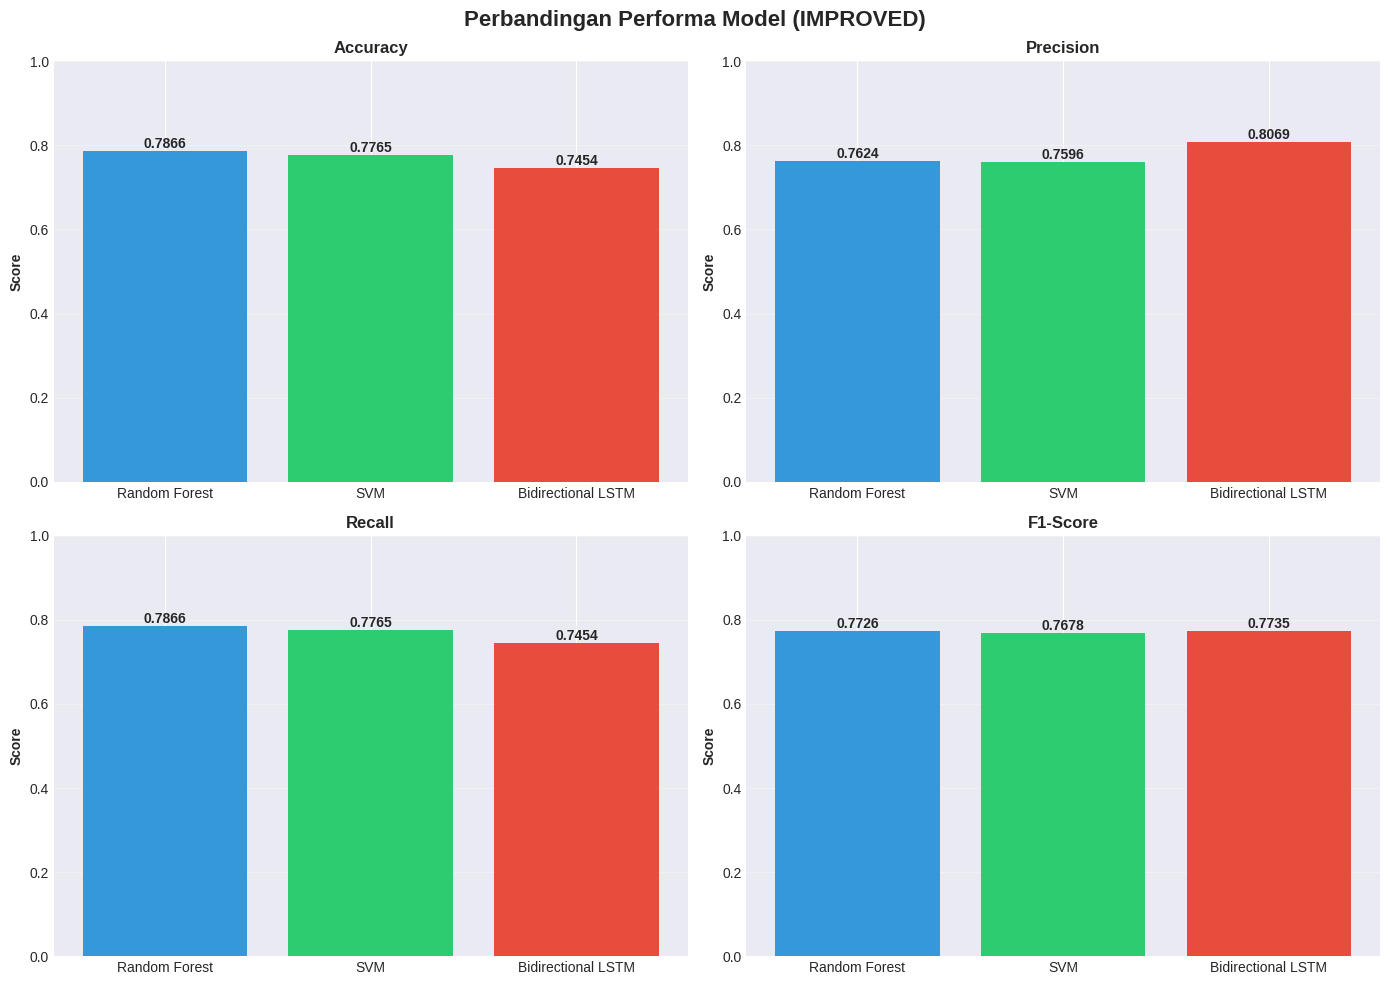

In [37]:
# Visualisasi perbandingan
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Perbandingan Performa Model (IMPROVED)', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#2ecc71', '#e74c3c']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]

    bars = ax.bar(df_results['Model'], df_results[metric], color=colors)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_ylabel('Score', fontweight='bold')
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)

    # Tambahkan nilai di atas bar
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [38]:
# Tabel perbandingan train, val, test
comparison_data = {
    'Model': ['Random Forest', 'SVM', 'Bidirectional LSTM'],
    'Train Accuracy': [
        f"{acc_train_rf*100:.2f}%",
        f"{acc_train_svm*100:.2f}%",
        f"{acc_train_lstm*100:.2f}%"
    ],
    'Val Accuracy': [
        f"{acc_val_rf*100:.2f}%",
        f"{acc_val_svm*100:.2f}%",
        f"{acc_val_lstm*100:.2f}%"
    ],
    'Test Accuracy': [
        f"{acc_test_rf*100:.2f}%",
        f"{acc_test_svm*100:.2f}%",
        f"{acc_test_lstm*100:.2f}%"
    ]
}

df_comparison = pd.DataFrame(comparison_data)

print("\nPerbandingan Akurasi pada Setiap Dataset:")
print(df_comparison.to_string(index=False))


Perbandingan Akurasi pada Setiap Dataset:
             Model Train Accuracy Val Accuracy Test Accuracy
     Random Forest         89.70%       81.71%        78.66%
               SVM         98.52%       79.39%        77.65%
Bidirectional LSTM         90.57%       77.80%        74.54%


## PREDICTION FUNCTIONS

In [39]:
def predict_sentiment(text, model_type='lstm'):
    """
    Fungsi untuk memprediksi sentimen dari teks baru
    """
    # Preprocessing
    cleaned_text = preprocess_text(text)

    # Mapping sentimen
    sentiment_names = {0: 'Negatif', 1: 'Netral', 2: 'Positif'}
    sentiment_emoji = {0: '😞', 1: '😐', 2: '😊'}

    if model_type.lower() == 'rf':
        # Random Forest
        text_tfidf = tfidf_vectorizer.transform([cleaned_text])
        prediction = rf_model.predict(text_tfidf)[0]
        probabilities = rf_model.predict_proba(text_tfidf)[0]
        model_name = 'Random Forest'

    elif model_type.lower() == 'svm':
        # SVM
        text_tfidf = tfidf_vectorizer.transform([cleaned_text])
        prediction = svm_model.predict(text_tfidf)[0]
        probabilities = svm_model.predict_proba(text_tfidf)[0]
        model_name = 'SVM'

    else:  # LSTM
        # LSTM
        text_seq = tokenizer.texts_to_sequences([cleaned_text])
        text_pad = pad_sequences(text_seq, maxlen=MAX_LEN, padding='post', truncating='post')
        probabilities = lstm_model.predict(text_pad, verbose=0)[0]
        prediction = np.argmax(probabilities)
        model_name = 'Bidirectional LSTM'

    return {
        'model': model_name,
        'text_asli': text,
        'text_bersih': cleaned_text,
        'prediksi': sentiment_names[prediction],
        'emoji': sentiment_emoji[prediction],
        'confidence': probabilities[prediction],
        'probabilitas': {
            'Negatif': probabilities[0],
            'Netral': probabilities[1],
            'Positif': probabilities[2]
        }
    }


def display_prediction(result):
    """
    Menampilkan hasil prediksi dengan format yang rapi
    """
    print("=" * 80)
    print(f"MODEL: {result['model']}")
    print("=" * 80)
    print(f"\n📝 Teks Asli:")
    print(f"   {result['text_asli']}")
    print(f"\n🧹 Teks Setelah Preprocessing:")
    print(f"   {result['text_bersih']}")
    print(f"\n🎯 Prediksi Sentimen: {result['prediksi']} {result['emoji']}")
    print(f"   Confidence: {result['confidence']*100:.2f}%")
    print(f"\n📊 Probabilitas Detail:")
    for sentiment, prob in result['probabilitas'].items():
        bar = '█' * int(prob * 50)
        print(f"   {sentiment:8s}: {prob*100:5.2f}% {bar}")
    print("=" * 80)


print("✓ Fungsi prediksi siap digunakan!")

✓ Fungsi prediksi siap digunakan!


## TESTING PREDICTIONS

In [40]:
# Contoh review untuk testing
test_reviews = [
    "Game nya keren banget! Grafisnya bagus, gameplay seru. Recommended!",
    "Biasa aja sih, gak terlalu istimewa tapi juga gak jelek",
    "Jelek banget! Banyak bug, sering lag, matchmaking tidak adil. Kecewa!",
    "Update terbaru sangat memuaskan, hero baru menarik dan balance lebih baik",
    "Aplikasi sering crash dan koneksi terputus saat ranked match"
]

print("\n" + "="*80)
print("TESTING DENGAN CONTOH REVIEW BARU")
print("="*80)


TESTING DENGAN CONTOH REVIEW BARU


In [41]:
# Test dengan Random Forest
print("\n" + "#"*80)
print("# PREDIKSI MENGGUNAKAN RANDOM FOREST")
print("#"*80)

for idx, review in enumerate(test_reviews, 1):
    print(f"\n--- Contoh {idx} ---")
    result = predict_sentiment(review, model_type='rf')
    display_prediction(result)


################################################################################
# PREDIKSI MENGGUNAKAN RANDOM FOREST
################################################################################

--- Contoh 1 ---
MODEL: Random Forest

📝 Teks Asli:
   Game nya keren banget! Grafisnya bagus, gameplay seru. Recommended!

🧹 Teks Setelah Preprocessing:
   game nya keren banget grafis bagus gameplay seru recommended

🎯 Prediksi Sentimen: Positif 😊
   Confidence: 79.83%

📊 Probabilitas Detail:
   Negatif : 10.43% █████
   Netral  :  9.75% ████
   Positif : 79.83% ███████████████████████████████████████

--- Contoh 2 ---


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      |

MODEL: Random Forest

📝 Teks Asli:
   Biasa aja sih, gak terlalu istimewa tapi juga gak jelek

🧹 Teks Setelah Preprocessing:
   biasa sih terlalu istimewa juga jelek

🎯 Prediksi Sentimen: Negatif 😞
   Confidence: 55.27%

📊 Probabilitas Detail:
   Negatif : 55.27% ███████████████████████████
   Netral  : 17.51% ████████
   Positif : 27.22% █████████████

--- Contoh 3 ---
MODEL: Random Forest

📝 Teks Asli:
   Jelek banget! Banyak bug, sering lag, matchmaking tidak adil. Kecewa!

🧹 Teks Setelah Preprocessing:
   tidak jelek banget banyak error sering lambat matchmaking adil kecewa

🎯 Prediksi Sentimen: Negatif 😞
   Confidence: 65.78%

📊 Probabilitas Detail:
   Negatif : 65.78% ████████████████████████████████
   Netral  : 18.80% █████████
   Positif : 15.42% ███████

--- Contoh 4 ---
MODEL: Random Forest

📝 Teks Asli:
   Update terbaru sangat memuaskan, hero baru menarik dan balance lebih baik

🧹 Teks Setelah Preprocessing:
   update baru sangat muas hero baru tarik balance lebih baik

🎯 

[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 300 out of 300 | elapsed:    0.0s finished


In [42]:
# Test dengan SVM
print("\n" + "#"*80)
print("# PREDIKSI MENGGUNAKAN SVM")
print("#"*80)

for idx, review in enumerate(test_reviews, 1):
    print(f"\n--- Contoh {idx} ---")
    result = predict_sentiment(review, model_type='svm')
    display_prediction(result)


################################################################################
# PREDIKSI MENGGUNAKAN SVM
################################################################################

--- Contoh 1 ---
MODEL: SVM

📝 Teks Asli:
   Game nya keren banget! Grafisnya bagus, gameplay seru. Recommended!

🧹 Teks Setelah Preprocessing:
   game nya keren banget grafis bagus gameplay seru recommended

🎯 Prediksi Sentimen: Positif 😊
   Confidence: 90.30%

📊 Probabilitas Detail:
   Negatif :  7.54% ███
   Netral  :  2.16% █
   Positif : 90.30% █████████████████████████████████████████████

--- Contoh 2 ---
MODEL: SVM

📝 Teks Asli:
   Biasa aja sih, gak terlalu istimewa tapi juga gak jelek

🧹 Teks Setelah Preprocessing:
   biasa sih terlalu istimewa juga jelek

🎯 Prediksi Sentimen: Negatif 😞
   Confidence: 63.89%

📊 Probabilitas Detail:
   Negatif : 63.89% ███████████████████████████████
   Netral  :  3.91% █
   Positif : 32.20% ████████████████

--- Contoh 3 ---
MODEL: SVM

📝 Teks Asli:
   Je

In [43]:
# Test dengan LSTM
print("\n" + "#"*80)
print("# PREDIKSI MENGGUNAKAN BIDIRECTIONAL LSTM")
print("#"*80)

for idx, review in enumerate(test_reviews, 1):
    print(f"\n--- Contoh {idx} ---")
    result = predict_sentiment(review, model_type='lstm')
    display_prediction(result)


################################################################################
# PREDIKSI MENGGUNAKAN BIDIRECTIONAL LSTM
################################################################################

--- Contoh 1 ---
MODEL: Bidirectional LSTM

📝 Teks Asli:
   Game nya keren banget! Grafisnya bagus, gameplay seru. Recommended!

🧹 Teks Setelah Preprocessing:
   game nya keren banget grafis bagus gameplay seru recommended

🎯 Prediksi Sentimen: Positif 😊
   Confidence: 98.29%

📊 Probabilitas Detail:
   Negatif :  1.03% 
   Netral  :  0.67% 
   Positif : 98.29% █████████████████████████████████████████████████

--- Contoh 2 ---
MODEL: Bidirectional LSTM

📝 Teks Asli:
   Biasa aja sih, gak terlalu istimewa tapi juga gak jelek

🧹 Teks Setelah Preprocessing:
   biasa sih terlalu istimewa juga jelek

🎯 Prediksi Sentimen: Negatif 😞
   Confidence: 75.69%

📊 Probabilitas Detail:
   Negatif : 75.69% █████████████████████████████████████
   Netral  :  9.29% ████
   Positif : 15.03% ███████

--

In [44]:
# Custom prediction
custom_review = "Sangat menghibur, tapi terkadang ada bug kecil"
print("\nPREDIKSI CUSTOM REVIEW:")
result = predict_sentiment(custom_review, model_type='lstm')
display_prediction(result)


PREDIKSI CUSTOM REVIEW:
MODEL: Bidirectional LSTM

📝 Teks Asli:
   Sangat menghibur, tapi terkadang ada bug kecil

🧹 Teks Setelah Preprocessing:
   sangat hibur terkadang error kecil

🎯 Prediksi Sentimen: Positif 😊
   Confidence: 89.69%

📊 Probabilitas Detail:
   Negatif :  8.72% ████
   Netral  :  1.58% 
   Positif : 89.69% ████████████████████████████████████████████


In [45]:
# Tampilkan kembali hasil perbandingan
print("\n" + "="*80)
print("PERFORMA AKHIR SEMUA MODEL")
print("="*80)
print(df_results.to_string(index=False))
print("\n" + "="*80)
print(f"🏆 MODEL TERBAIK: {best_model}")
print(f"📈 AKURASI TESTING: {best_accuracy*100:.2f}%")
print("="*80)


PERFORMA AKHIR SEMUA MODEL
             Model  Accuracy  Precision   Recall  F1-Score
     Random Forest  0.786647   0.762406 0.786647  0.772553
               SVM  0.776488   0.759640 0.776488  0.767798
Bidirectional LSTM  0.745375   0.806893 0.745375  0.773467

🏆 MODEL TERBAIK: Random Forest
📈 AKURASI TESTING: 78.66%


## SAVE MODELS

In [46]:
# Save model (opsional)
print("\n💾 Menyimpan model...")

# Simpan model LSTM
lstm_model.save('model_lstm_mlbb_improved.h5')
print("✓ Model LSTM disimpan: model_lstm_mlbb_improved.h5")

# Simpan tokenizer
import pickle

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("✓ Tokenizer disimpan: tokenizer.pkl")

# Simpan TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print("✓ TF-IDF Vectorizer disimpan: tfidf_vectorizer.pkl")

# Simpan Random Forest
with open('model_rf_improved.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print("✓ Model Random Forest disimpan: model_rf_improved.pkl")

# Simpan SVM
with open('model_svm_improved.pkl', 'wb') as f:
    pickle.dump(svm_model, f)
print("✓ Model SVM disimpan: model_svm_improved.pkl")

print("\n✅ Semua model berhasil disimpan!")


💾 Menyimpan model...
✓ Model LSTM disimpan: model_lstm_mlbb_improved.h5
✓ Tokenizer disimpan: tokenizer.pkl
✓ TF-IDF Vectorizer disimpan: tfidf_vectorizer.pkl
✓ Model Random Forest disimpan: model_rf_improved.pkl
✓ Model SVM disimpan: model_svm_improved.pkl

✅ Semua model berhasil disimpan!
